In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [7]:
df = pd.read_csv("D:\Mumbai-Housing-Saturation\data\processed\mumbai_hpi_clean.csv")
print(df.head())

      quarter         hpi     time
0  Q1.2010-11   88.820870  2010.00
1  Q2.2010-11   98.671878  2010.25
2  Q3.2010-11  104.745752  2010.50
3  Q4.2010-11  107.761499  2010.75
4  Q1.2011-12  118.001952  2011.00


In [8]:
def logistic(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

p0 = [500, 0.3, 2016]

params, covariance = curve_fit(logistic, df['time'], df['hpi'], p0=p0, maxfev=10000)

K, r, t0 = params
print(f"Saturation Level (K): {K:.2f}")
print(f"Growth Rate (r):       {r:.4f}")
print(f"Inflection Year (t0):  {t0:.2f}")

Saturation Level (K): 424.02
Growth Rate (r):       0.3934
Inflection Year (t0):  2013.64


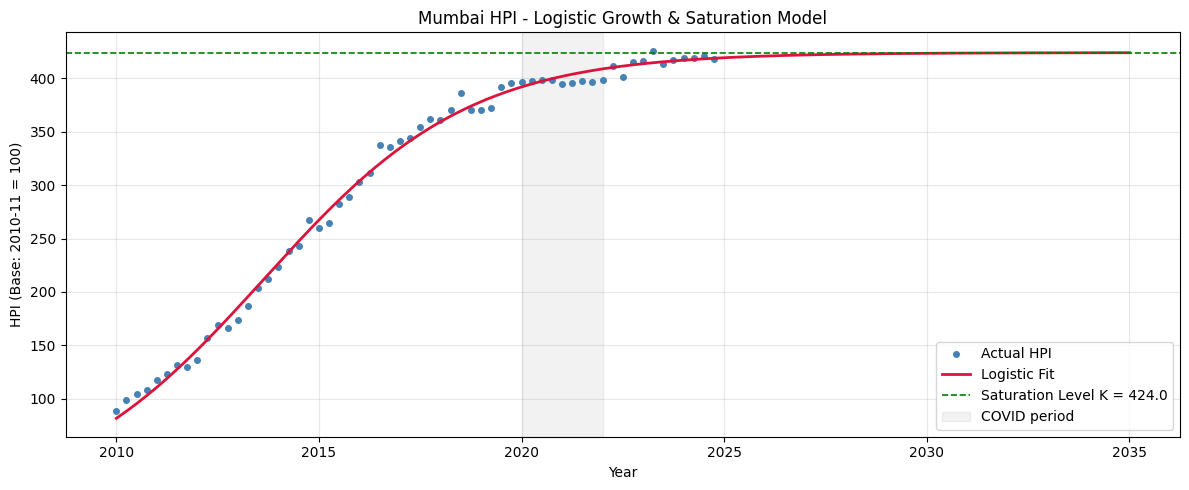

In [9]:
t_range = np.linspace(df['time'].min(), 2035, 300)
hpi_pred = logistic(t_range, K, r, t0)

plt.figure(figsize=(12, 5))
plt.plot(df['time'], df['hpi'], 'o', markersize=4, label='Actual HPI', color='steelblue')
plt.plot(t_range, hpi_pred, '-', linewidth=2, label='Logistic Fit', color='crimson')
plt.axhline(K, color='green', linestyle='--', linewidth=1.2, label=f'Saturation Level K = {K:.1f}')
plt.axvspan(2020, 2022, alpha=0.1, color='gray', label='COVID period')
plt.title('Mumbai HPI - Logistic Growth & Saturation Model')
plt.xlabel('Year')
plt.ylabel('HPI (Base: 2010-11 = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/mumbai_hpi_saturation_model.png', dpi=150)
plt.show()

In [10]:
results = {
    'saturation_level_K': round(K, 2),
    'growth_rate_r': round(r, 4),
    'inflection_year_t0': round(t0, 2),
    'current_hpi': round(df['hpi'].iloc[-1], 2),
    'saturation_gap': round(K - df['hpi'].iloc[-1], 2)
}

import json
with open('../outputs/results/saturation_model_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print(results)

{'saturation_level_K': np.float64(424.02), 'growth_rate_r': np.float64(0.3934), 'inflection_year_t0': np.float64(2013.64), 'current_hpi': np.float64(417.8), 'saturation_gap': np.float64(6.22)}


## Saturation Model Results

**Model:** Logistic Growth (S-curve)  
**Fitted on:** Mumbai HPI quarterly data, Q1 2010-11 to Q4 2024-25 (76 observations)

| Parameter | Value | Interpretation |
|---|---|---|
| K (Saturation Level) | 424.02 | HPI ceiling the market is converging toward |
| r (Growth Rate) | 0.3934 | Rate of growth — moderately steep |
| t₀ (Inflection Year) | 2013.64 | Peak growth velocity was around mid-2013 |

## Key Conclusion
Mumbai's housing market, as measured by RBI HPI (base 2010-11=100), is **effectively at saturation**.  
Current HPI (~418) is within 1.4% of the model's predicted ceiling of 424.  
The market entered its plateau phase around 2019-2020, with COVID temporarily suppressing an already decelerating trend.

> Note: Saturation here refers to the index on the 2010-11 base. Absolute prices may still rise under a rebased index — as evidenced by RBI's